In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [55]:
#importing the dataset
df = pd.read_csv("wine_data.csv")

In [56]:
#displaying the dataset
df.head(10)

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5




---

Question 1. What is the most frequently occurring wine quality? What is the highest number in and the lowest number in the quantity column?


---



In [57]:
#finding the various types of wine qualities
df["quality"].unique()

array([5, 6, 7, 4, 8, 3])

In [58]:
#counting the various types of wine quality
count={}
for value in df["quality"]:
  if value in count:
    count[value]+=1
  else:
    count[value]=1

print(count)

{5: 681, 6: 638, 7: 199, 4: 53, 8: 18, 3: 10}


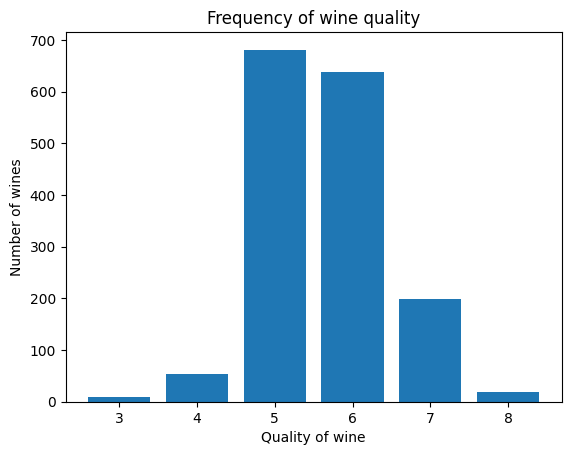

In [59]:
#visual representation using bar graph
plt.bar(count.keys(), count.values())
plt.xlabel("Quality of wine")
plt.ylabel("Number of wines")
plt.title("Frequency of wine quality")
plt.show()



---

Question 2. How is `fixed acidity` correlated to the quality of the wine? How does the alcohol content affect the quality? How is the `free Sulphur dioxide` content correlated to the quality of the wine?


---



In [60]:
#correlation matrix
correlation_matrix=df[["quality", "fixed acidity", "free sulfur dioxide", "alcohol"]].corr()
print(correlation_matrix)

                      quality  fixed acidity  free sulfur dioxide   alcohol
quality              1.000000       0.124052            -0.050656  0.476166
fixed acidity        0.124052       1.000000            -0.153794 -0.061668
free sulfur dioxide -0.050656      -0.153794             1.000000 -0.069408
alcohol              0.476166      -0.061668            -0.069408  1.000000


<Axes: >

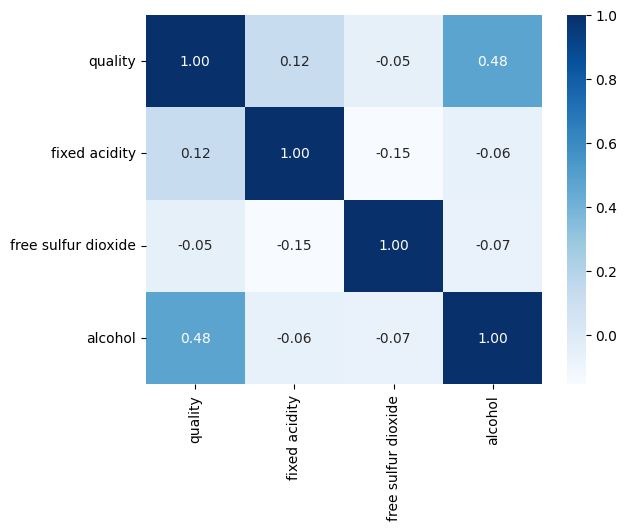

In [61]:
#visual representation of correlation matrix using heatmap
import seaborn as sns
sns.heatmap(correlation_matrix, cmap="Blues", annot=True, fmt = ".2f")



---

Question 3. What is the average `residual sugar` for the best quality wine and the lowest quality wine in the dataset?


---



In [62]:
#grouping the dataset over quality and calculating the mean
df.groupby("quality").mean()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol
quality,,,,,,,,,,,
3,8.360000,0.884500,0.171000,2.635000,0.122500,11.000000,24.900000,0.997464,3.398000,0.570000,9.955000
4,7.779245,0.693962,0.174151,2.694340,0.090679,12.264151,36.245283,0.996542,3.381509,0.596415,10.265094
5,8.167254,0.577041,0.243686,2.528855,0.092736,16.983847,56.513950,0.997104,3.304949,0.620969,9.899706
6,8.347179,0.497484,0.273824,2.477194,0.084956,15.711599,40.869906,0.996615,3.318072,0.675329,10.629519
7,8.872362,0.403920,0.375176,2.720603,0.076588,14.045226,35.020101,0.996104,3.290754,0.741256,11.465913
8,8.566667,0.423333,0.391111,2.577778,0.068444,13.277778,33.444444,0.995212,3.267222,0.767778,12.094444




---

Question 4. Does `volatile acidity` has an effect over the quality of the wine samples in the dataset?


---



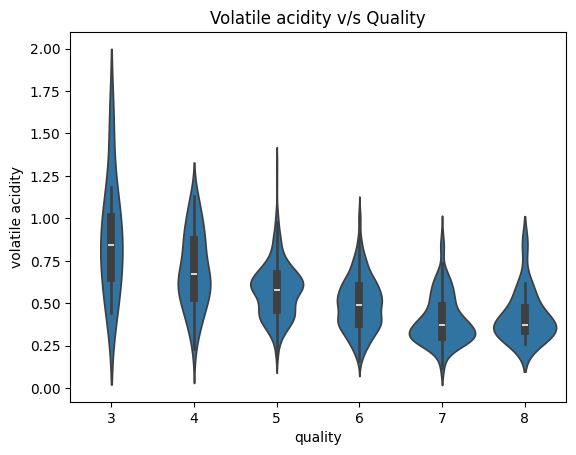

In [63]:
#using violin plot to observe the relationship between volatile acidity and quality of wine
sns.violinplot(x="quality", y="volatile acidity", data=df)
plt.title("Volatile acidity v/s Quality")
plt.show()

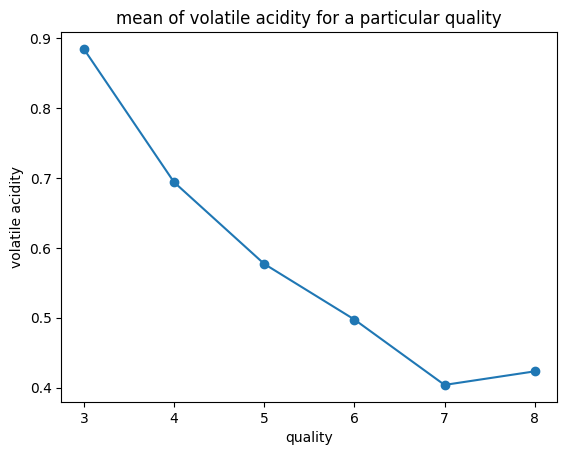

In [64]:
#nature of volatile acidity against quality
df.groupby("quality")["volatile acidity"].mean().plot(marker='o')
plt.title("mean of volatile acidity for a particular quality")
plt.ylabel("volatile acidity")
plt.show()

In [65]:
#correlation matrix to find numerical relation
correlation_matrix_2=df[["quality", "volatile acidity"]].corr()
print(correlation_matrix_2)

                   quality  volatile acidity
quality           1.000000         -0.390558
volatile acidity -0.390558          1.000000




---

Question 5. Train a Decision Tree model and Random Forest Model separately to predict the Quality of the given samples of wine. Compare the Accuracy scores for both models.


---



In [66]:
#defining x and y variables
x=df.drop(["quality"], axis=1)
y=df["quality"]

In [67]:
#splitting the dataset
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=0)

In [68]:
#preprocessing
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [41]:
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [69]:
#training the decision tree model
from sklearn.tree import DecisionTreeClassifier
classifier=DecisionTreeClassifier(criterion="entropy", random_state=0)
classifier.fit(x_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [70]:
#predicitng the quality of wine
y_pred=classifier.predict(x_test)

In [71]:
#accuracy score for decision tree model
from sklearn.metrics import accuracy_score
accuracy_score(y_test, y_pred)

0.634375

In [72]:
#training random forest model
from sklearn.ensemble import RandomForestClassifier
classifier_1=RandomForestClassifier(n_estimators=10, criterion="entropy", random_state=0)
classifier_1.fit(x_train, y_train)

RandomForestClassifier(criterion='entropy', n_estimators=10, random_state=0)

In [73]:
#predicting the quality of wine
y_pred_1=classifier_1.predict(x_test)

In [74]:
#accuracy score for random froest model
accuracy_score(y_test, y_pred_1)

0.66875